In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("compiled_model_with_return2y.csv")  # Ganti path jika perlu
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by=['Saham', 'Date'])
data.set_index('Date', inplace=True)

In [3]:
def arima_pipeline(data, saham_name):
    data_saham = data[data['Saham'] == saham_name]
    ts = data_saham['Close'].asfreq('B').fillna(method='ffill')

    adf_pvalue = adfuller(ts)[1]
    train_len = math.ceil(len(ts) * 0.8)
    train, test = ts[:train_len], ts[train_len:]

    p, d, q = range(0, 4), range(0, 3), range(0, 4)
    pdq = list(product(p, d, q))
    best_aic = float('inf')
    best_order = None
    for order in pdq:
        try:
            model = ARIMA(train, order=order)
            result = model.fit()
            if result.aic < best_aic:
                best_aic = result.aic
                best_order = order
        except:
            continue
    final_model = ARIMA(train, order=best_order).fit()
    forecast = final_model.forecast(len(test))
    forecast.index = test.index

    mse = mean_squared_error(test, forecast)
    rmse = math.sqrt(mse)
    rmse_ratio = rmse / test.mean()

    plt.figure(figsize=(12, 5))
    plt.plot(train, label='Train')
    plt.plot(test, label='Actual')
    plt.plot(forecast, label='Forecast')
    plt.title(f'{saham_name} Forecast (ARIMA {best_order})')
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return {
        "Saham": saham_name,
        "ADF_pvalue": round(adf_pvalue, 5),
        "Best_ARIMA": best_order,
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "RMSE/Mean": round(rmse_ratio, 5)
    }

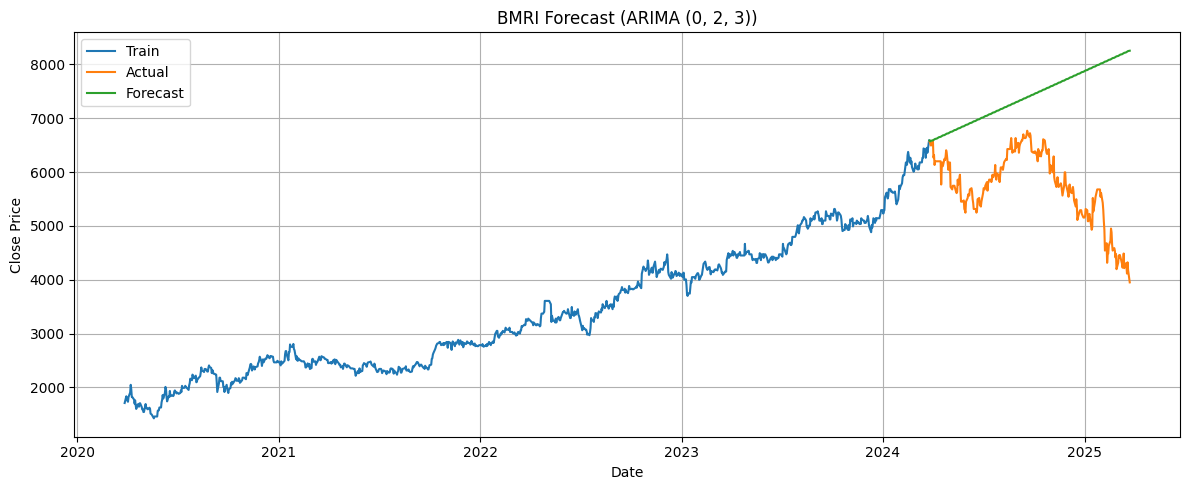

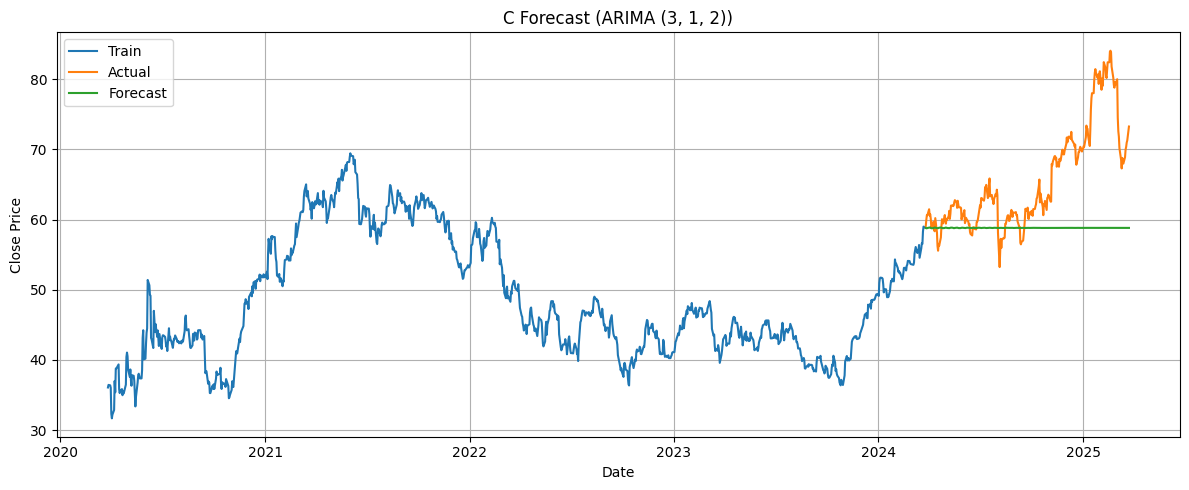

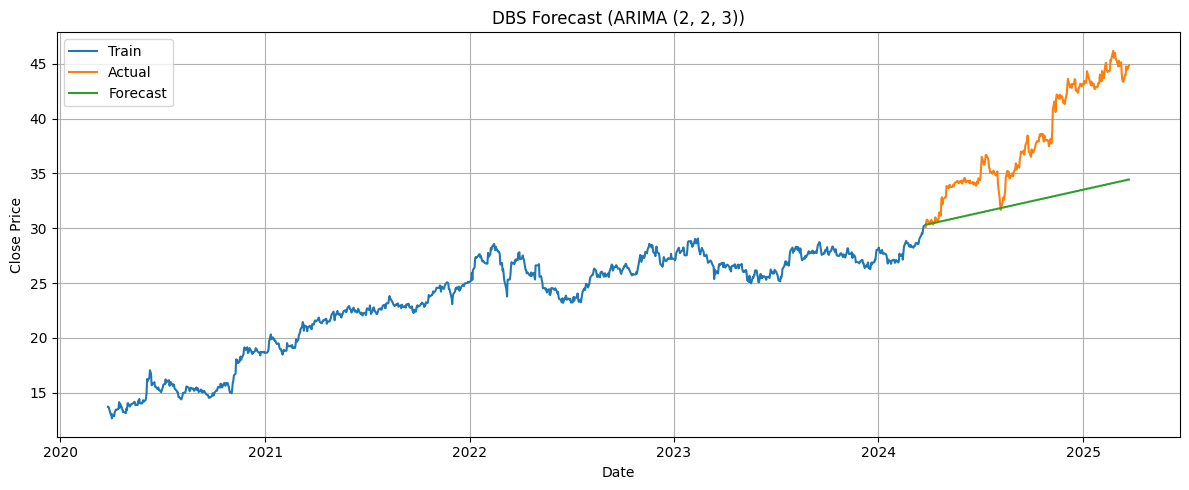

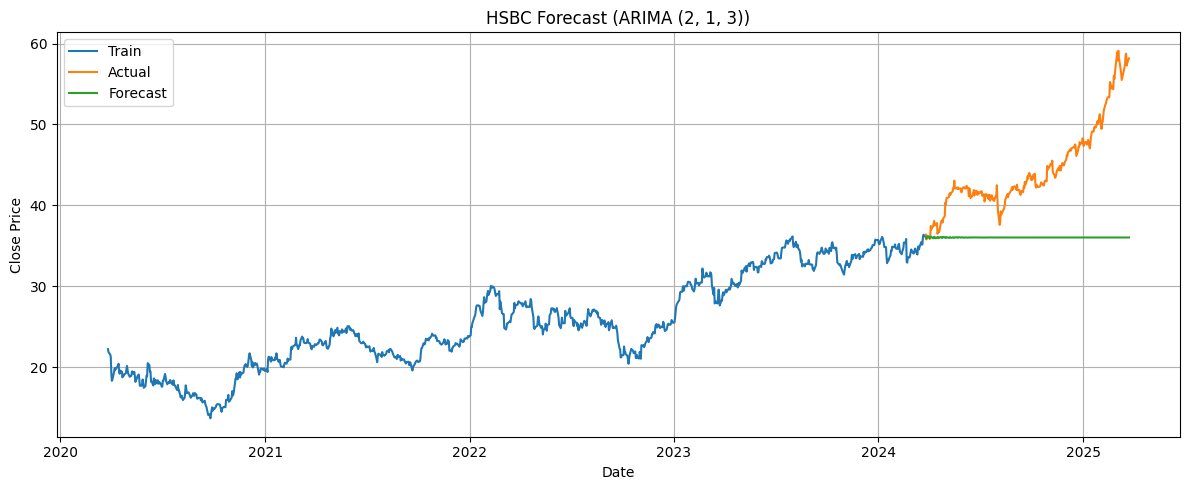

In [4]:
result_arima = []
for saham in data['Saham'].unique():
    result_arima.append(arima_pipeline(data, saham))

arima_df = pd.DataFrame(result_arima)

In [5]:
data_return = data.dropna(subset=['Return_2y'])
mean_return = data_return.groupby('Saham')['Return_2y'].mean().reset_index()
mean_return.columns = ['Saham', 'Mean_Return_2y']

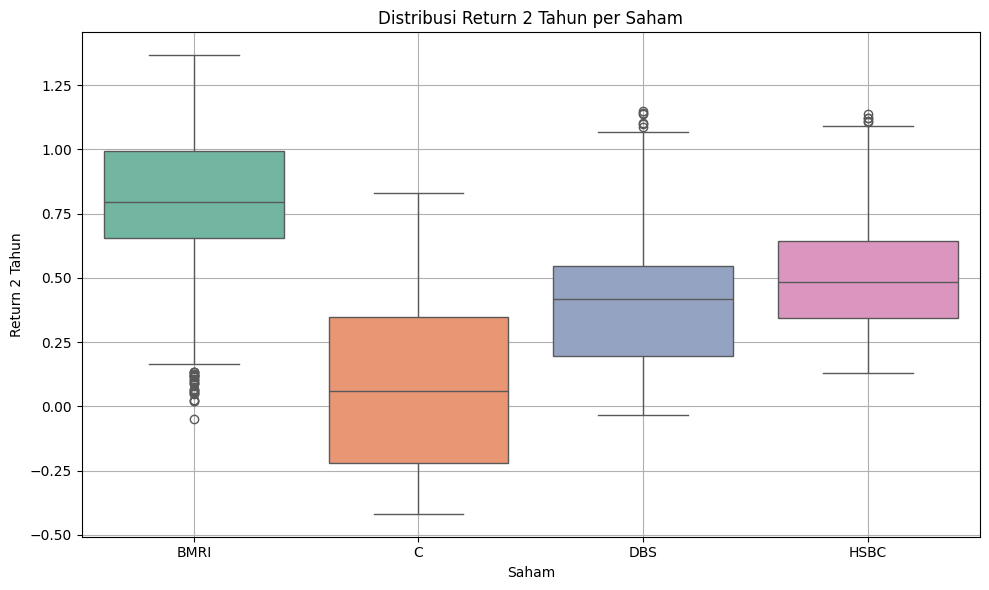

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_return, x='Saham', y='Return_2y', palette='Set2')
plt.title("Distribusi Return 2 Tahun per Saham")
plt.ylabel("Return 2 Tahun")
plt.grid(True)
plt.tight_layout()
plt.show()
final_result = pd.merge(arima_df, mean_return, on='Saham')


In [7]:
latest_data = data_return.sort_values("Date").groupby("Saham").tail(1)
latest_data["Buy_Price"] = latest_data["Close"]
latest_data["Expected_Sell_Price"] = latest_data["Buy_Price"] * (1 + latest_data["Return_2y"])
latest_data["Return (%)"] = latest_data["Return_2y"] * 100

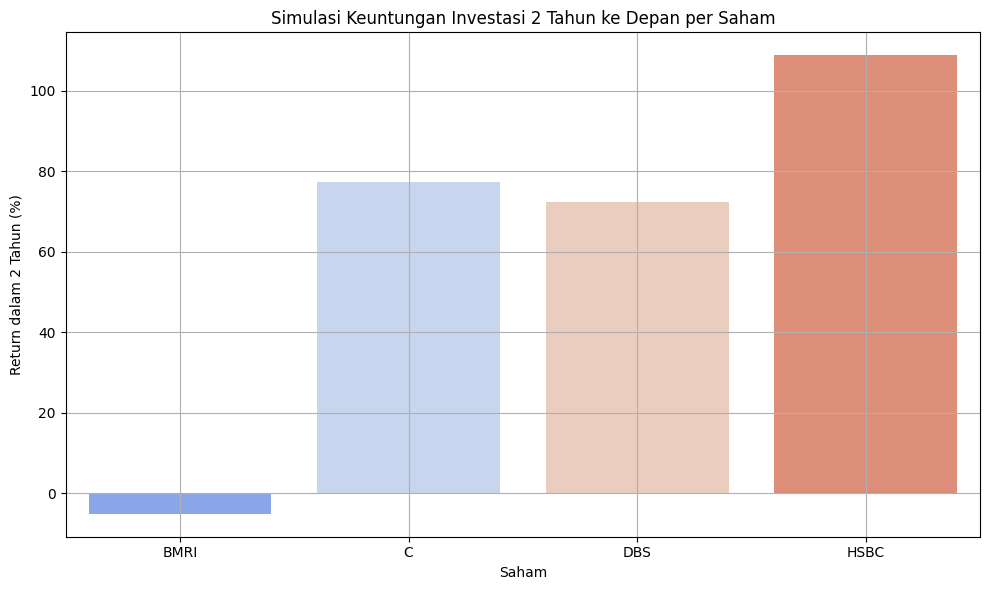

In [8]:
simulasi_data = latest_data[["Saham", "Buy_Price", "Expected_Sell_Price", "Return (%)"]].reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=simulasi_data, x="Saham", y="Return (%)", palette="coolwarm")
plt.title("Simulasi Keuntungan Investasi 2 Tahun ke Depan per Saham")
plt.ylabel("Return dalam 2 Tahun (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

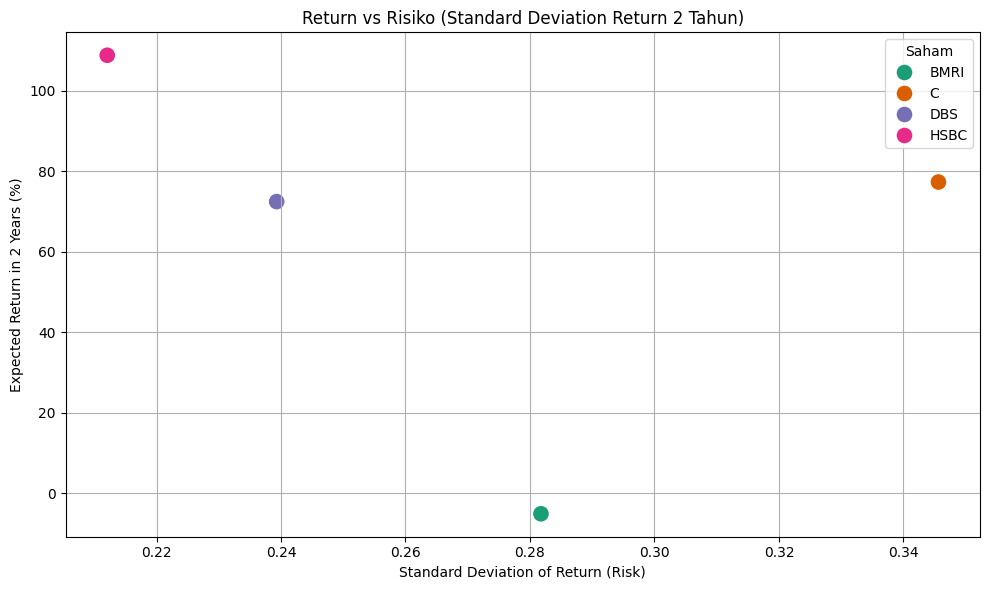

In [9]:
std_return = data_return.groupby("Saham")["Return_2y"].std().reset_index()
std_return.columns = ["Saham", "Return_2y_STD"]
simulasi_risk_data = pd.merge(simulasi_data, std_return, on="Saham")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=simulasi_risk_data,
    x="Return_2y_STD",
    y="Return (%)",
    hue="Saham",
    s=150,
    palette="Dark2"
)
plt.title("Return vs Risiko (Standard Deviation Return 2 Tahun)")
plt.xlabel("Standard Deviation of Return (Risk)")
plt.ylabel("Expected Return in 2 Years (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
simulasi_risk_data["Risk_Adjusted_Return"] = simulasi_risk_data["Return (%)"] / simulasi_risk_data["Return_2y_STD"]

simulasi_sorted = simulasi_risk_data.sort_values("Risk_Adjusted_Return", ascending=False).reset_index(drop=True)

def rekomendasi(row):
    if row["Return (%)"] < 0:
        return "Tidak Disarankan (Return Negatif)"
    elif row["Risk_Adjusted_Return"] > 300:
        return "Sangat Disarankan"
    elif row["Risk_Adjusted_Return"] > 200:
        return "Disarankan"
    elif row["Risk_Adjusted_Return"] > 100:
        return "Pertimbangkan"
    else:
        return "Risiko Tinggi, Return Rendah"

simulasi_sorted["Recommendation"] = simulasi_sorted.apply(rekomendasi, axis=1)

In [11]:
import plotly.express as px
import plotly.graph_objects as go

fig_rank = px.bar(
    simulasi_sorted,
    x='Saham',
    y='Risk_Adjusted_Return',
    color='Recommendation',
    text='Risk_Adjusted_Return',
    title='Ranking Saham Berdasarkan Risk-Adjusted Return',
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig_rank.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig_rank.update_layout(yaxis_title="Risk-Adjusted Return", xaxis_title="Saham", uniformtext_minsize=8)
fig_rank.show()

In [12]:
categories = ['Return (%)', 'Return_2y_STD', 'Risk_Adjusted_Return']
radar_df = simulasi_sorted.copy()
radar_df.set_index('Saham', inplace=True)

fig_radar = go.Figure()
for saham in radar_df.index:
    fig_radar.add_trace(go.Scatterpolar(
        r=radar_df.loc[saham, categories].values,
        theta=categories,
        fill='toself',
        name=saham
    ))
fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title="Perbandingan Metrik Saham (Radar Chart)",
    showlegend=True
)
fig_radar.show()

In [13]:
output_path = "Rekomendasi_Saham_ARIMA_Return2Y.csv"
simulasi_sorted.to_csv(output_path, index=False)

output_path

'Rekomendasi_Saham_ARIMA_Return2Y.csv'

Kesimpulan :

Analisis ini membuktikan pentingnya pendekatan berbasis data dan model prediksi seperti ARIMA dalam analisis saham. Dengan penggabungan analisis return dan risiko, investor atau perusahaan dapat mengidentifikasi saham yang efisien secara objektif.
HSBC dan DBS adalah pilihan paling optimal.
Citigroup cocok untuk investor berisiko tinggi.
BMRI sebaiknya dihindari untuk jangka menengah.
